FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

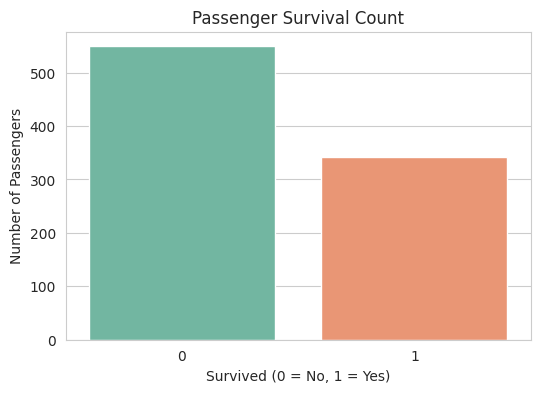

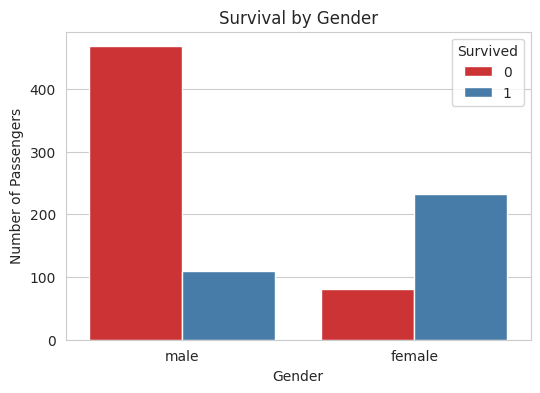

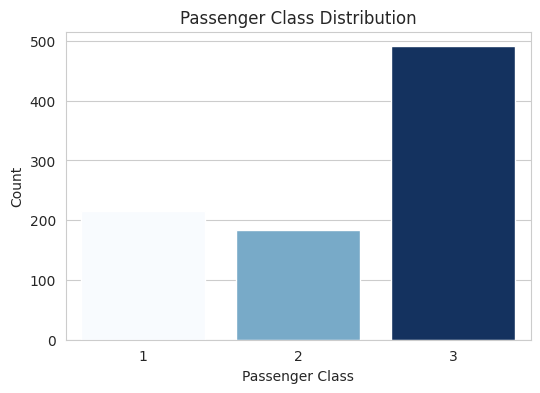

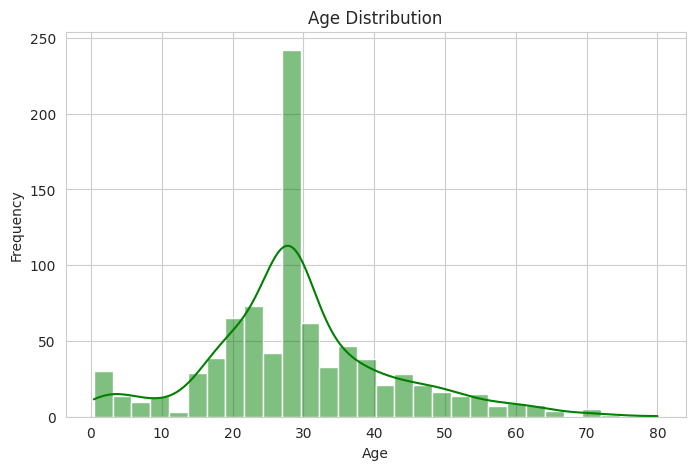

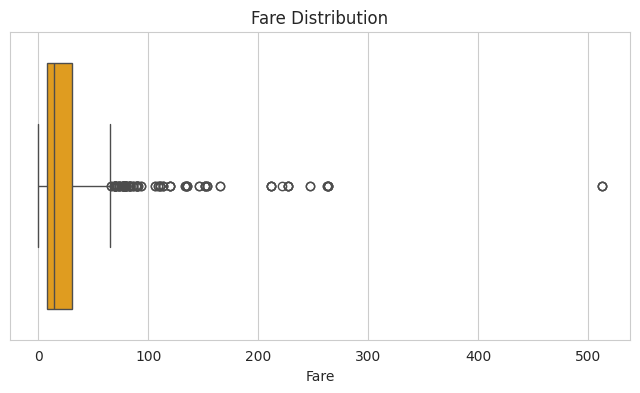

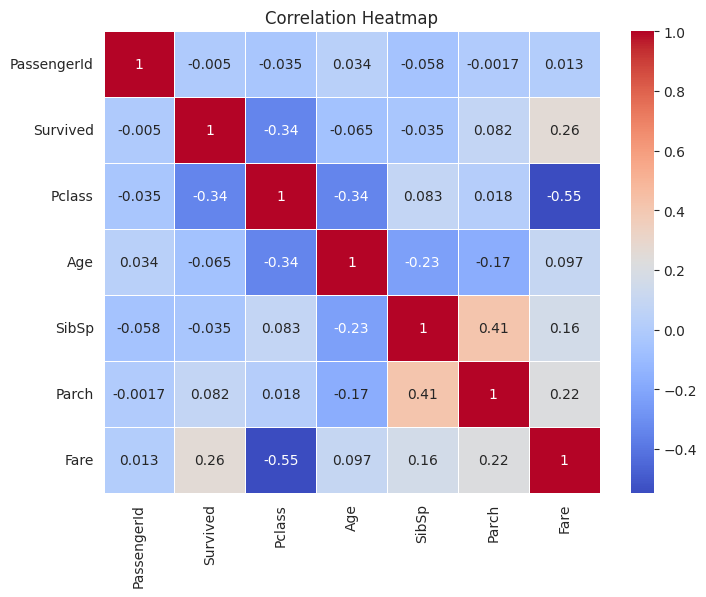


DATA STORY

Average Age
29.36158249158249

Average Fare
32.204207968574636

Passenger Survival Count
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class Distribution
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Gender Distribution
Sex
male      577
female    314
Name: count, dtype: int64

Embarkation Port
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Average Fare by Passenger Class
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Average Age by Gender
Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

Survival Rate by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Cleaned dataset saved successfully as
'cleaned_titanic_storytelling.csv'

All graphs have been saved successfully.


In [1]:
# ==========================================
# TASK 2
# Advanced Data Visualization and Storytelling
# Titanic Dataset
# ==========================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("train.csv")

print("="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\nDataset Shape:", df.shape)

# ==========================================
# Data Cleaning
# ==========================================

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop(columns=["Cabin"], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ==========================================
# Visualization 1
# Passenger Survival Count
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived", hue="Survived", palette="Set2", legend=False)
plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.savefig("graph1_survival_count.png")
plt.show()

# ==========================================
# Visualization 2
# Survival by Gender
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set1")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.savefig("graph2_survival_gender.png")
plt.show()

# ==========================================
# Visualization 3
# Passenger Class Distribution
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Pclass", hue="Pclass", palette="Blues", legend=False)
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.savefig("graph3_passenger_class.png")
plt.show()

# ==========================================
# Visualization 4
# Age Distribution
# ==========================================

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True, color="green")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("graph4_age_distribution.png")
plt.show()

# ==========================================
# Visualization 5
# Fare Distribution (Box Plot)
# ==========================================

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Fare"], color="orange")
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.savefig("graph5_fare_boxplot.png")
plt.show()

# ==========================================
# Visualization 6
# Correlation Heatmap
# ==========================================

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.savefig("graph6_heatmap.png")
plt.show()

# ==========================================
# Storytelling Statistics
# ==========================================

print("\n" + "="*50)
print("DATA STORY")
print("="*50)

print("\nAverage Age")
print(df["Age"].mean())

print("\nAverage Fare")
print(df["Fare"].mean())

print("\nPassenger Survival Count")
print(df["Survived"].value_counts())

print("\nPassenger Class Distribution")
print(df["Pclass"].value_counts())

print("\nGender Distribution")
print(df["Sex"].value_counts())

print("\nEmbarkation Port")
print(df["Embarked"].value_counts())

print("\nAverage Fare by Passenger Class")
print(df.groupby("Pclass")["Fare"].mean())

print("\nAverage Age by Gender")
print(df.groupby("Sex")["Age"].mean())

print("\nSurvival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean())

print("\nSurvival Rate by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean())

# ==========================================
# Save Cleaned Dataset
# ==========================================

df.to_csv("cleaned_titanic_storytelling.csv", index=False)

print("\nCleaned dataset saved successfully as")
print("'cleaned_titanic_storytelling.csv'")

print("\nAll graphs have been saved successfully.")